In [2]:
import requests
import pandas as pd

df = pd.read_csv(r"C:\Projects\Tisini\Visualization\Leagues Tornaments Friendlies\Equity\Men\Equity FC 2025-26 Player Analysis with Per 90.csv")

In [ ]:
df.head

In [23]:
df.shape

(43, 60)

In [ ]:
df.columns

In [3]:
# Create a separate dataframe for defensive analysis
def_df = df[
    [
        "Player",
        "Position",
        "Estimated Minutes",
        "Estimated 90s",
        
        # Tackling
        "Tackles Won /90",
        "Tackles Lost /90",
        "Total Tackles",
        "Tackle Success Rate %",
        
        # Interceptions
        "Interceptions /90",
        
        # Defensive actions
        "Clearances",
        "Blocks",
        
        # Possession recovery
        "Ball Won Own /90",
        "Ball Own Lost /90",
        
        # Aerials
        "Aerial Duels Won",
        "Aerial Duels Total",
        "Aerial Duels %",
    ]
].copy()

# Minimum playing-time filter
MIN_MINUTES = 400

def_df_400 = def_df[
    def_df["Estimated Minutes"] >= MIN_MINUTES
].copy()

In [4]:
# Create per-90 defensive metrics that are not already provided

def_df["Clearances /90"] = (def_df["Clearances"] / def_df["Estimated 90s"])

def_df["Blocks /90"] = (def_df["Blocks"] / def_df["Estimated 90s"])

def_df["Aerial Duels Won /90"] = (def_df["Aerial Duels Won"] / def_df["Estimated 90s"])

def_df["Aerial Duels Total /90"] = (def_df["Aerial Duels Total"] / def_df["Estimated 90s"])


# Apply the same calculations to the 400+ minute dataset
def_df_400["Clearances /90"] = (def_df_400["Clearances"] / def_df_400["Estimated 90s"])

def_df_400["Blocks /90"] = (def_df_400["Blocks"] / def_df_400["Estimated 90s"])

def_df_400["Aerial Duels Won /90"] = (def_df_400["Aerial Duels Won"] / def_df_400["Estimated 90s"])

def_df_400["Aerial Duels Total /90"] = (def_df_400["Aerial Duels Total"] / def_df_400["Estimated 90s"])


# Display Check the new metrics
def_df_400[
    [
        "Player",
        "Clearances /90",
        "Blocks /90",
        "Aerial Duels Won /90",
        "Aerial Duels Total /90"
    ]
].round(2).head()

,Player,Clearances /90,Blocks /90,Aerial Duels Won /90,Aerial Duels Total /90
0,Abdi Abdi,2.74,0.26,0.13,0.13
1,Barrack Dago,6.29,0.97,0.65,0.91
2,Bernard Lusi,9.94,0.87,1.46,1.87
3,Bevex David,0.70,0.15,0.15,0.60
8,Elvis Odhiambo,2.67,0.39,0.46,0.59


One important decision

We're deliberately not using raw totals such as Clearances or Blocks on the radar. We've converted those to per-90 values, making the comparison much fairer.

Next, we'll take these eight metrics and convert them into 0–100 percentile scores among the selected comparison group (def_df_400 for now).

That's where the radar starts becoming genuinely useful.

In [6]:
# Metrics used for the defensive radar

defensive_metrics = {
    "Tackling": "Tackles Won /90",
    "Tackle Efficiency": "Tackle Success Rate %",
    "Interceptions": "Interceptions /90",
    "Clearances": "Clearances /90",
    "Blocks": "Blocks /90",
    "Ball Recovery": "Ball Won Own /90",
    "Aerial Success": "Aerial Duels %",
    "Aerial Volume": "Aerial Duels Won /90"
}

print("Defensive radar metrics:")
for label, column in defensive_metrics.items():
    print(f"{label}: {column}")

Defensive radar metrics:
Tackling: Tackles Won /90
Tackle Efficiency: Tackle Success Rate %
Interceptions: Interceptions /90
Clearances: Clearances /90
Blocks: Blocks /90
Ball Recovery: Ball Won Own /90
Aerial Success: Aerial Duels %
Aerial Volume: Aerial Duels Won /90


In [7]:
# Create a copy for percentile calculations
radar_df = def_df_400.copy()

# Calculate percentile scores for each defensive metric
for label, column in defensive_metrics.items():
    radar_df[f"{label} Score"] = (radar_df[column].rank(pct=True) * 100)

# Score columns
score_columns = [f"{label} Score" for label in defensive_metrics]

# Inspect the scores
radar_df[["Player"] + score_columns].round(1).head()

,Player,Tackling Score,Tackle Efficiency Score,Interceptions Score,Clearances Score,Blocks Score,Ball Recovery Score,Aerial Success Score,Aerial Volume Score
0,Abdi Abdi,23.5,23.5,64.7,70.6,52.9,82.4,20.6,23.5
1,Barrack Dago,70.6,94.1,94.1,94.1,94.1,38.2,70.6,88.2
2,Bernard Lusi,88.2,82.4,88.2,100.0,88.2,52.9,79.4,100.0
3,Bevex David,47.1,61.8,23.5,29.4,41.2,17.6,35.3,41.2
8,Elvis Odhiambo,23.5,23.5,76.5,64.7,70.6,100.0,79.4,82.4


In [8]:
from mplsoccer import Radar

# Radar labels
params = list(defensive_metrics.keys())

# Radar scale
low = [0] * len(params)
high = [100] * len(params)

# Select player by name
player_name = "Michael Onyango"

player_data = radar_df[radar_df["Player"] == player_name].iloc[0]

# Extract player's percentile scores
values = [player_data[f"{metric} Score"] for metric in params]

# Check the values
print(f"Player: {player_name}")
print()

for param, value in zip(params, values):
    print(f"{param}: {value:.1f}")

Player: Michael Onyango

Tackling: 23.5
Tackle Efficiency: 23.5
Interceptions: 5.9
Clearances: 5.9
Blocks: 8.8
Ball Recovery: 5.9
Aerial Success: 8.8
Aerial Volume: 8.8


In [9]:
# Inspect all position values in the 400+ minute dataset
position_counts = (radar_df["Position"].value_counts(dropna=False))

position_counts

Position
Winger                  4
Midfielder              4
Fullback                3
Centre Back             3
Attacking Midfielder    1
Goalkeeper              1
Striker                 1
Name: count, dtype: int64

In [10]:
# Positions included in the defensive comparison
defender_positions = ["Centre Back", "Fullback"]

# Filter to defenders only
defenders_df = radar_df[radar_df["Position"].isin(defender_positions)].copy()

# Check the result
print(f"Defenders with 400+ minutes: {len(defenders_df)}")
print()

print(defenders_df["Position"].value_counts())

Defenders with 400+ minutes: 6

Position
Fullback       3
Centre Back    3
Name: count, dtype: int64


In [11]:
defenders_df[["Player", "Position", "Estimated Minutes"]].sort_values("Estimated Minutes", ascending=False)

,Player,Position,Estimated Minutes
2,Bernard Lusi,Centre Back,3087.2
12,Isaac Owiyo,Fullback,2525.7
21,Song Wingston,Centre Back,2162.5
1,Barrack Dago,Centre Back,1387.3
0,Abdi Abdi,Fullback,1378.3
24,Vinedine Ambetsa,Fullback,1276.0


In [12]:
# Defender-only radar dataset
radar_df = def_df_400[def_df_400["Position"].isin(["Centre Back", "Fullback"])].copy()

# Calculate percentile scores within defenders only
for label, column in defensive_metrics.items():
    radar_df[f"{label} Score"] = (radar_df[column].rank(pct=True) * 100)

# Score columns
score_columns = [f"{label} Score" for label in defensive_metrics]

# View defender scores
radar_df[["Player", "Position"] + score_columns].round(1)

,Player,Position,Tackling Score,Tackle Efficiency Score,Interceptions Score,Clearances Score,Blocks Score,Ball Recovery Score,Aerial Success Score,Aerial Volume Score
0,Abdi Abdi,Fullback,16.7,16.7,16.7,16.7,16.7,83.3,25.0,16.7
1,Barrack Dago,Centre Back,50.0,100.0,83.3,83.3,83.3,16.7,50.0,83.3
2,Bernard Lusi,Centre Back,83.3,66.7,66.7,100.0,66.7,50.0,66.7,100.0
12,Isaac Owiyo,Fullback,33.3,50.0,33.3,50.0,33.3,33.3,25.0,33.3
21,Song Wingston,Centre Back,66.7,33.3,50.0,66.7,100.0,66.7,83.3,50.0
24,Vinedine Ambetsa,Fullback,100.0,83.3,100.0,33.3,50.0,100.0,100.0,66.7


In [13]:
# Display defender percentile scores

display(radar_df[["Player", "Position"] + score_columns].sort_values("Player").round(1))

,Player,Position,Tackling Score,Tackle Efficiency Score,Interceptions Score,Clearances Score,Blocks Score,Ball Recovery Score,Aerial Success Score,Aerial Volume Score
0,Abdi Abdi,Fullback,16.7,16.7,16.7,16.7,16.7,83.3,25.0,16.7
1,Barrack Dago,Centre Back,50.0,100.0,83.3,83.3,83.3,16.7,50.0,83.3
2,Bernard Lusi,Centre Back,83.3,66.7,66.7,100.0,66.7,50.0,66.7,100.0
12,Isaac Owiyo,Fullback,33.3,50.0,33.3,50.0,33.3,33.3,25.0,33.3
21,Song Wingston,Centre Back,66.7,33.3,50.0,66.7,100.0,66.7,83.3,50.0
24,Vinedine Ambetsa,Fullback,100.0,83.3,100.0,33.3,50.0,100.0,100.0,66.7


In [14]:
from mplsoccer import Radar
import matplotlib.pyplot as plt

# Radar parameters
params = list(defensive_metrics.keys())

# Percentile scale
low = [0] * len(params)
high = [100] * len(params)

# Create the radar
radar = Radar(
    params=params,
    min_range=low,
    max_range=high,
    round_int=[False] * len(params),
    num_rings=4,
    ring_width=1,
    center_circle_radius=1
)

print("Radar created successfully.")

Radar created successfully.


In [15]:
# Calculate the average percentile score across all defenders

defender_average = [radar_df[f"{metric} Score"].mean() for metric in params]

# Display the benchmark
for metric, value in zip(params, defender_average):
    print(f"{metric}: {value:.1f}")

Tackling: 58.3
Tackle Efficiency: 58.3
Interceptions: 58.3
Clearances: 58.3
Blocks: 58.3
Ball Recovery: 58.3
Aerial Success: 58.3
Aerial Volume: 58.3


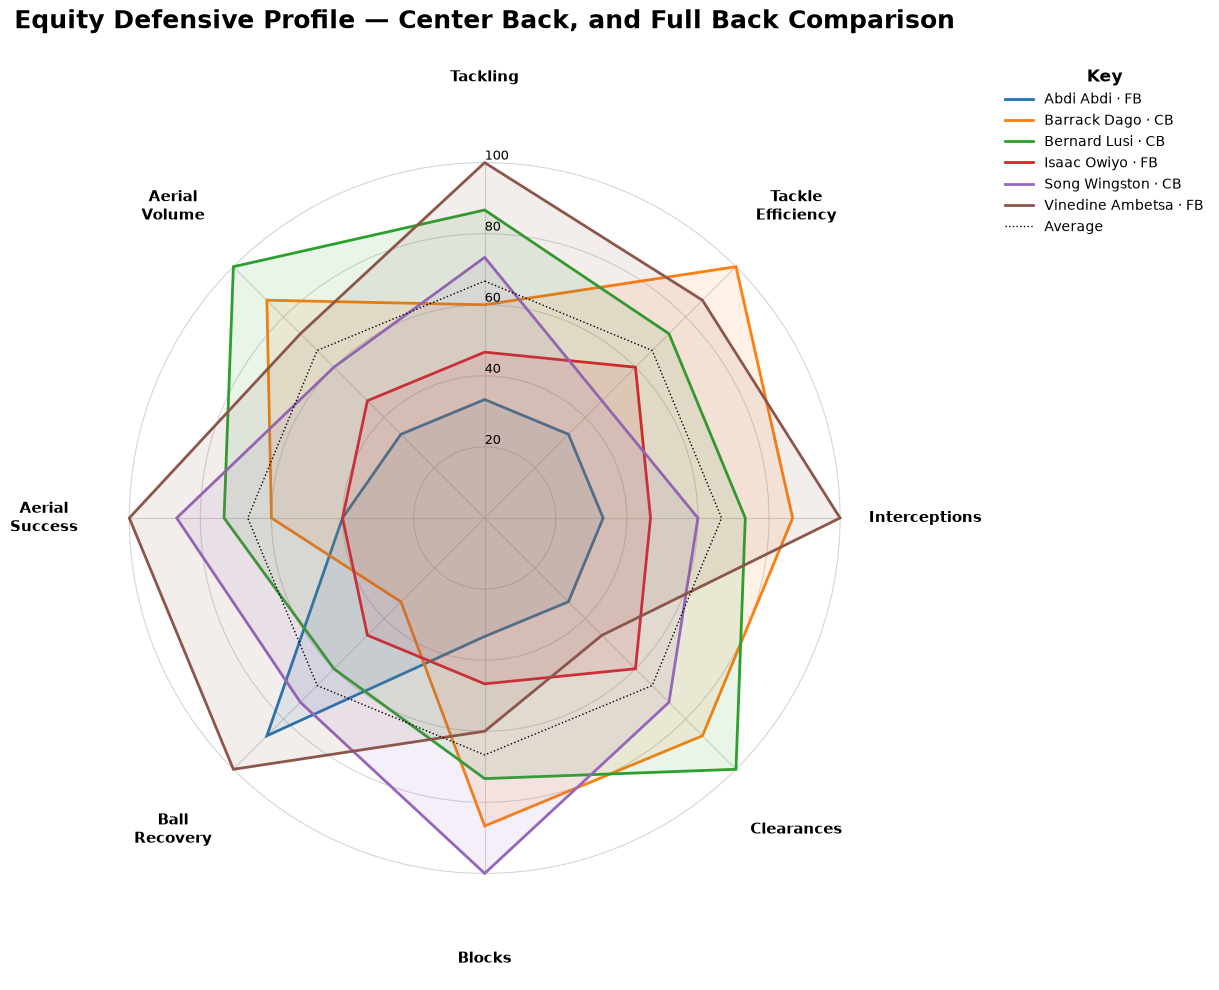

In [18]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle

fig, ax = radar.setup_axis()

plt.rcParams["font.family"] = "sans-serif"

# Colours for each defender
colors = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b"
]


legend_items = []


# --------------------------------
# Draw the Lines
# --------------------------------

# Draw subtle lines connecting the center to each metric
for x, y in zip(radar.rotation_sin, radar.rotation_cos):
    ax.plot(
        [0, x * radar.outer_ring],
        [0, y * radar.outer_ring],
        linewidth=0.8,
        color="#cccccc",
        alpha=0.8,
        zorder=0
    )

# --------------------------------
# Draw the radar rings ONCE
# --------------------------------

# Draw subtle inner grid circles only
for radius in [1, 2, 3, 4, 5]:
    ax.add_patch(
        Circle(
            (0, 0),
            radius,
            fill=False,
            linewidth=0.8,
            edgecolor="#cccccc",
            alpha=0.8
        )
    )

# --------------------------------
# Draw individual defenders
# --------------------------------

position_abbr = {
    "Centre Back": "CB",
    "Fullback": "FB",
    "Winger": "WNG",
    "Attacking Midfielder": "AM",
    "Striker": "ST"
}

for i, (_, player) in enumerate(radar_df.iterrows()):

    values = [player[f"{metric} Score"] for metric in params]

    # Light filled polygon
    radar._draw_radar(
        values,
        ax=ax,
        facecolor=colors[i],
        edgecolor="none",
        alpha=0.1
    )

    # Strong polygon outline
    radar._draw_radar(
        values,
        ax=ax,
        facecolor="none",
        edgecolor=colors[i],
        linewidth=2
    )

    legend_items.append(
        Line2D(
            [0],
            [0],
            color=colors[i],
            linewidth=2,
            label=f'{player["Player"]} · {position_abbr[player["Position"]]}'
        )
    )

# --------------------------------
# Draw defender average
# --------------------------------

radar._draw_radar(
    defender_average,
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1,
    linestyle=":"
)

legend_items.append(
    Line2D(
        [0],
        [0],
        color="black",
        linewidth=1,
        linestyle=":",
        label="Average"
    )
)

# --------------------------------
# Legend
# --------------------------------

legend = ax.legend(
    handles=legend_items,
    loc="upper left",
    bbox_to_anchor=(1.05, 1),
    frameon=False,
    title="Key"
)

legend.get_title().set_fontweight("bold")
legend.get_title().set_fontsize(12)

ax.set_title(
    "Equity Defensive Profile — Center Back, and Full Back Comparison",
    fontsize=18,
    pad=20,
    fontweight="bold"
)

# Add metric labels around the radar
# Straight, stacked metric labels

param_radius = radar.outer_ring + 1.2

param_xs = param_radius * radar.rotation_sin
param_ys = param_radius * radar.rotation_cos

for label, x, y in zip(params, param_xs, param_ys):
    ax.text(
        x,
        y,
        label.replace(" ", "\n"),
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="center",
        rotation=0
    )

# Add percentile/range labels
for value in [20, 40, 60, 80, 100]:
    radius = radar.outer_ring * (value/100)

    ax.text(
        0,
        radius,
        str(value),
        fontsize=9,
        ha="left",
        va="bottom"
    )

plt.show()

In [23]:
print(radar_df["Player"].tolist())

['Abdi Abdi', 'Barrack Dago', 'Bernard Lusi', 'Isaac Owiyo', 'Song Wingston', 'Vinedine Ambetsa']


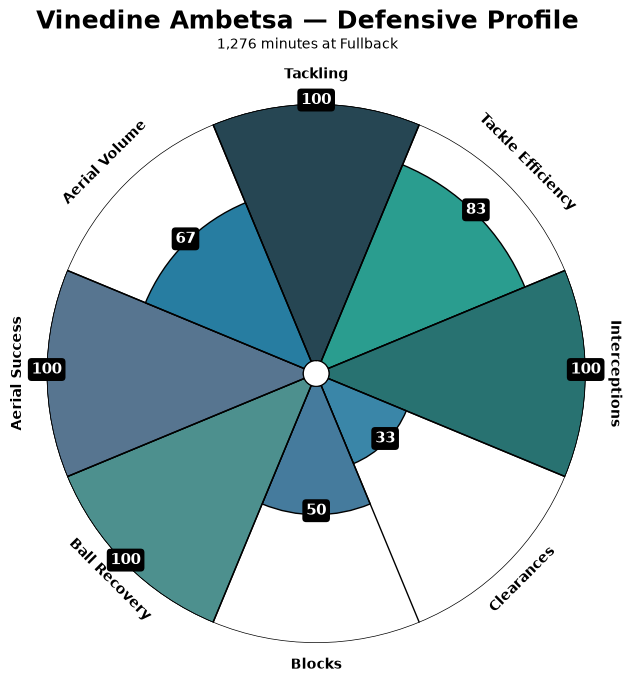

In [74]:
from mplsoccer import PyPizza
import matplotlib.pyplot as plt

# --------------------------------
# Pizza setup
# --------------------------------

pizza = PyPizza(
    params=params,
    background_color='white',
    straight_line_color="#000000",
    straight_line_lw=1,
    last_circle_lw=1,
    other_circle_lw=0,
    other_circle_color='#000000',
    other_circle_ls='--'
)

# --------------------------------
# Select player
# --------------------------------

player_name = "Vinedine Ambetsa"

player_data = radar_df[radar_df["Player"] == player_name].iloc[0]

# --------------------------------
# Extract percentile scores
# --------------------------------

values = [
    round(player_data[f"{metric} Score"])
    for metric in params
]

# --------------------------------
# Create pizza
# --------------------------------

fig, ax = pizza.make_pizza(
    values,
    figsize=(7, 7),

    # Move parameter labels further away
    param_location=110,

    # Pizza slices
    slice_colors=[
        "#264653",
        "#2A9D8F",
        "#287271",
        "#3A86A8",
        "#457B9D",
        "#4D908E",
        "#577590",
        "#277DA1"
    ],

    # Value numbers
    value_colors=["white"] * len(params),
    value_bck_colors=["black"] * len(params),

    kwargs_slices=dict(
        edgecolor="black",
        linewidth=1,
        zorder=1
    ),

    # Parameter labels
    kwargs_params=dict(
        color="#000000",
        fontsize=10,
        fontweight="bold"
    ),

    # Percentile numbers
    kwargs_values=dict(
        color="white",
        fontsize=11,
        fontweight="bold",
        bbox=dict(
            edgecolor="none",
            facecolor="#4C78A8",
            boxstyle="round,pad=0.25"
        )
    )
)

# --------------------------------
# Title
# --------------------------------

fig.text(
    0.5,
    1.015,
    f"{player_name} — Defensive Profile",
    fontsize=18,
    fontweight="bold",
    ha="center",
    va="top"
)

# --------------------------------
# Subtitle
# --------------------------------

fig.text(
    0.5,
    0.975,
    f"{int(player_data['Estimated Minutes']):,} minutes at {player_data['Position']}",
    fontsize=10,
    ha="center",
    va="top"
)

plt.show()